<a href="https://colab.research.google.com/github/sharare-bazdar/Sharare-/blob/main/class_2_sequentional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow import keras
#from tensorflow.keras import keras
from sklearn.linear_model import Perceptron
from keras.datasets import california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error
import numpy as np
import matplotlib as plt
from tensorflow.keras import layers

In [ ]:
(x_train,y_train),(x_test,y_test)=california_housing.load_data()

743530/743530 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(16512, 8) (16512,) (4128, 8) (4128,)


In [ ]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
model=keras.Sequential([
    layers.Dense(64, activation='relu',input_shape=(x_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',loss='mean_squared_error',metrics=['mae'])

In [ ]:
history=model.fit(x_train,y_train,epochs=100,validation_split=0.2,batch_size=32,verbose=1)

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 54955253760.0000 - mae: 204892.2500 - val_loss: 56377966592.0000 - val_mae: 206967.2031
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 54898855936.0000 - mae: 204192.7656 - val_loss: 53999722496.0000 - val_mae: 201693.2656
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 52833505280.0000 - mae: 199243.7656 - val_loss: 48568512512.0000 - val_mae: 189129.9531
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 45673295872.0000 - mae: 182521.5312 - val_loss: 40550051840.0000 - val_mae: 168978.0156
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 37294747648.0000 - mae: 160736.2812 - val_loss: 31645925376.0000 - val_mae: 144465.0938
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 29279944704.0000 - mae: 137544.8750 - val_loss: 23733843968.0000 - val_mae: 120536.5703
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 21830578176.0000 - mae: 114217.4844 - val_los

In [ ]:
test_loss,test_mae=model.evaluate(x_test,y_test)
print(f'test mean absolute error:{test_mae:0.2f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4780952576.0000 - mae: 49850.4805
test mean absolute error:48420.35


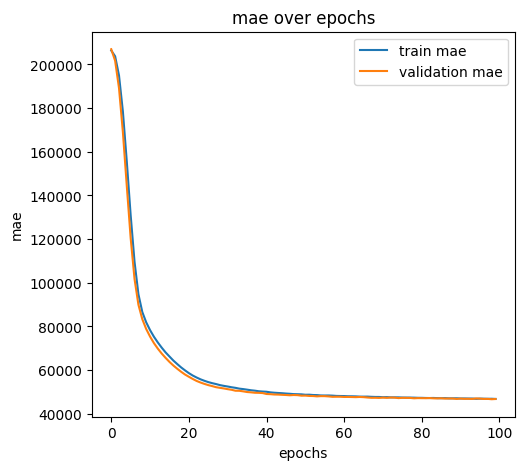

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['mae'],label='train mae')
plt.plot(history.history['val_mae'],label='validation mae')
plt.title('mae over epochs')
plt.xlabel('epochs')
plt.ylabel('mae')
plt.legend()

In [ ]:
y_pred=model.predict(x_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


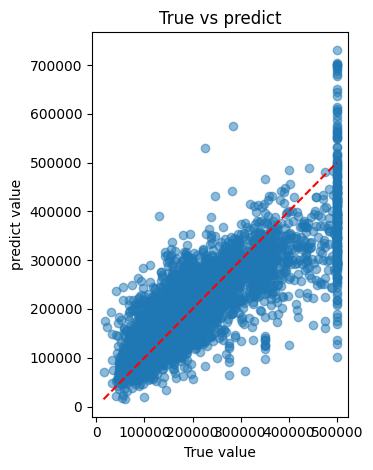

In [ ]:
plt.subplot(1,2,2)
plt.scatter(y_test,y_pred,alpha=0.5)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.title('True vs predict')
plt.xlabel('True value')
plt.ylabel('predict value')
plt.tight_layout()
plt.show()